# Lecture 3 — Player Experience Modeling in Digital Games
## Practical Exercise: Descriptive Profiling from Game Telemetry

---

### Overview

In this exercise you will work with **synthetic data** from a 2D arena game. The dataset mimics the kind of multi-modal data you would collect in a real UX study:

| File | Description |
|---|---|
| `telemetry_events.csv` | Per-timestep positional data + discrete events (shot, kill, death, hit_taken, pickup) |
| `session_summary.csv` | Per-session aggregated stats (kills, deaths, shots, …) |
| `likert.csv` | Post-session self-report scales (frustration, control, engagement, confusion) |

**Learning goals**
1. Load and clean telemetry data (handle NaNs, type issues)
2. Build and interpret spatial heatmaps
3. Apply rule-based player profiling
4. Apply data-driven (clustering) player profiling
5. Integrate telemetry with Likert-scale data

---

> **Arena quick-reference**  
> Coordinate space: 0–100 on both axes  
> Four spawn corners · Six pickup locations · Central objective zone (radius ≈ 12)  
> Five obstacle rectangles forming a cross shape with a central pillar


---
## Part 0 — Setup

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Reproducibility
np.random.seed(42)

# Arena constants (same as data generator)
OBSTACLES = [
    (35, 0, 45, 40),
    (55, 60, 65, 100),
    (0, 45, 40, 55),
    (60, 45, 100, 55),
    (45, 45, 55, 55),
]
SPAWNS   = [(10,10),(90,10),(10,90),(90,90)]
PICKUPS  = [(20,20),(80,20),(20,80),(80,80),(50,20),(50,80)]
CENTER   = (50, 50)

def draw_arena(ax, title='Arena Layout'):
    """Helper: draw obstacles, spawns, pickups on an existing Axes."""
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    for (x1,y1,x2,y2) in OBSTACLES:
        rect = patches.Rectangle((x1,y1), x2-x1, y2-y1,
                                  linewidth=1, edgecolor='grey',
                                  facecolor='lightsteelblue', alpha=0.6)
        ax.add_patch(rect)
    sx, sy = zip(*SPAWNS)
    ax.scatter(sx, sy, marker='s', s=80, color='steelblue', zorder=5, label='Spawn')
    px, py = zip(*PICKUPS)
    ax.scatter(px, py, marker='^', s=80, color='darkorange', zorder=5, label='Pickup')
    circle = plt.Circle(CENTER, 12, fill=False, linestyle='--', color='black', linewidth=1.5)
    ax.add_patch(circle)
    ax.legend(loc='upper right', fontsize=8)

print('Setup complete.')

Setup complete.


---
## Part 1 — Data Loading & Cleaning

The CSV files contain **intentionally introduced data quality issues**:
- Missing values (`NaN`) in numeric columns
- A small number of out-of-bounds coordinate rows
- Duplicate rows in the event log

Your job is to detect, report, and handle them before any analysis.

In [33]:
# ── Load the three tables ────────────────────────────────────────────────────
events   = pd.read_csv('telemetry_events.csv')
summary  = pd.read_csv('session_summary.csv')
likert   = pd.read_csv('likert.csv')

print('events shape  :', events.shape)
print('summary shape :', summary.shape)
print('likert shape  :', likert.shape)

events shape  : (1717736, 6)
summary shape : (1000, 9)
likert shape  : (1000, 6)


In [34]:
# ── 1.1  Inspect the first few rows of each table ───────────────────────────
events.head()

,session_id,player_id,t,x,y,event_type
0,S0166,P17,389.0,79.232881,77.179352,move
1,S0149,P15,500.0,9.402828,18.973471,move
2,S0220,P22,546.0,71.477306,87.378109,move
3,S0226,P23,907.0,42.397522,63.964016,move
4,S0346,P35,746.0,58.295166,56.225586,shot


In [35]:
summary.head()

,session_id,player_id,duration_s,kills,deaths,shots_fired,hits_taken,pickups,objective_progress
0,S0001,P1,1200.0,10.0,33.0,215.0,161.0,53.0,36.124072
1,S0002,P1,1200.0,15.0,33.0,230.0,190.0,68.0,38.450269
2,S0003,P1,1200.0,11.0,33.0,230.0,178.0,50.0,42.437401
3,S0004,P1,1200.0,10.0,35.0,236.0,183.0,56.0,42.914045
4,S0005,P1,1200.0,3.0,35.0,233.0,179.0,56.0,34.727311


In [36]:
likert.head()

,session_id,player_id,frustration,control,engagement,confusion
0,S0001,P1,5.0,3.0,6.0,3.0
1,S0002,P1,6.0,NaN,5.0,3.0
2,S0003,P1,7.0,2.0,5.0,NaN
3,S0004,P1,5.0,2.0,5.0,3.0
4,S0005,P1,6.0,5.0,5.0,3.0


In [37]:
# ── 1.2  Missing value audit ─────────────────────────────────────────────────
for name, df in [('events', events), ('summary', summary), ('likert', likert)]:
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    print(f'\n--- {name} ---')
    if len(missing):
        print(missing.to_string())
    else:
        print('No missing values.')


--- events ---
x    4807
y    2402

--- summary ---
kills                 20
deaths                20
shots_fired           20
hits_taken            20
pickups               20
objective_progress    20

--- likert ---
frustration    30
control        30
engagement     30
confusion      30


In [ ]:
# ── 1.3 Handle missing values ─────────────────────────────────────────
# Your task:
#  (a) Drop rows from `events` where x or y is NaN  (positional data is non-imputable)
#  (b) For `summary` numeric columns, fill NaN with the column median
#  (c) For `likert` Likert columns, fill NaN with the column median (round to nearest integer)
#
# Think: why is median preferred over mean for Likert scales?

# (a) Drop rows from `events` where x or y is NaN
events_clean = events.dropna(subset=['x', 'y'])

# (b) For `summary` numeric columns, fill NaN with the column median
numeric_cols = summary.select_dtypes(include=[np.number]).columns
summary_clean = summary.copy()
for col in numeric_cols:
    median_value = summary_clean[col].median()
    summary_clean[col] = summary_clean[col].fillna(median_value)
    
# (c) For `likert` Likert columns, fill NaN with the column median (round to nearest integer)
likert_clean = likert.copy()
likert_numeric_cols = likert_clean.select_dtypes(include=[np.number]).columns
for col in likert_numeric_cols:
    median_value = likert_clean[col].median()
    likert_clean[col] = likert_clean[col].fillna(round(median_value))
    
# Print summary of missing value handling
print('\nMissing values after cleaning:')
print('events:', events_clean.isnull().sum().sum())
print('summary:', summary_clean.isnull().sum().sum())
print('likert:', likert_clean.isnull().sum().sum())



Missing values after cleaning:
events: 0
summary: 0
likert: 0


In [ ]:
# ── 1.4  Remove out-of-bounds coordinates ──────────────────────────────
# Valid arena range: 0 ≤ x ≤ 100 and 0 ≤ y ≤ 100
# Report how many rows are affected, then drop them.

# Remove out-of-bounds coordinates
valid_events = events_clean[
    (events_clean['x'] >= 0) & (events_clean['x'] <= 100) &
    (events_clean['y'] >= 0) & (events_clean['y'] <= 100)
]

# Report how many rows were removed
removed_rows = events_clean.shape[0] - valid_events.shape[0]
print(f'\nRemoved {removed_rows} out-of-bounds rows from events.')


Removed 600 out-of-bounds rows from events.


In [ ]:
# ── 1.5  Remove duplicate event rows ───────────────────────────────────
# Hint: use pd.DataFrame.duplicated()

# Remove duplicate event rows, using pd.DataFrame.duplicated()
events_no_duplicates = valid_events.drop_duplicates()
events_no_duplicates.reset_index(drop=True, inplace=True)

# Report how many duplicate rows were removed
duplicate_rows = valid_events.shape[0] - events_no_duplicates.shape[0]
print(f'\nRemoved {duplicate_rows} duplicate rows from events.')


Removed 1705 duplicate rows from events.


---
## Part 2 — Spatial Heatmaps

Heatmaps let us see *where* players spend time and *where* key events occur. We will build them using 2D histogram binning.

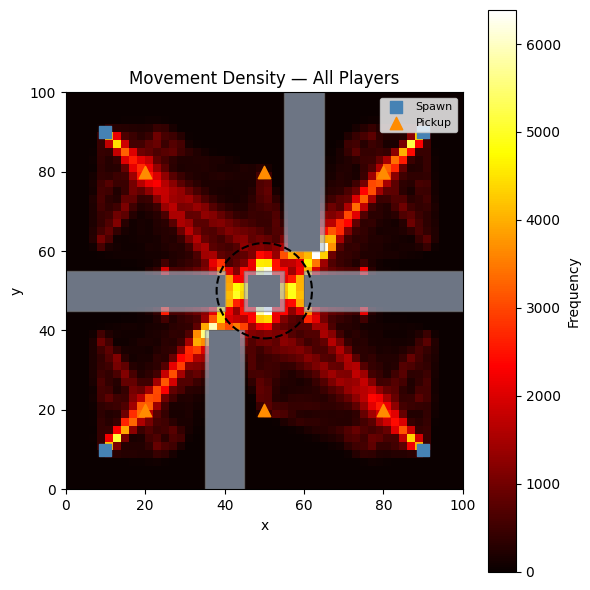

In [41]:
# ── 2.1  Movement density heatmap (all players, all sessions) ────────────────
move_df = events[events['event_type'] == 'move']

fig, ax = plt.subplots(figsize=(6, 6))
h = ax.hist2d(move_df['x'], move_df['y'], bins=50, cmap='hot', range=[[0,100],[0,100]])
plt.colorbar(h[3], ax=ax, label='Frequency')
draw_arena(ax, title='Movement Density — All Players')
plt.tight_layout()
plt.show()

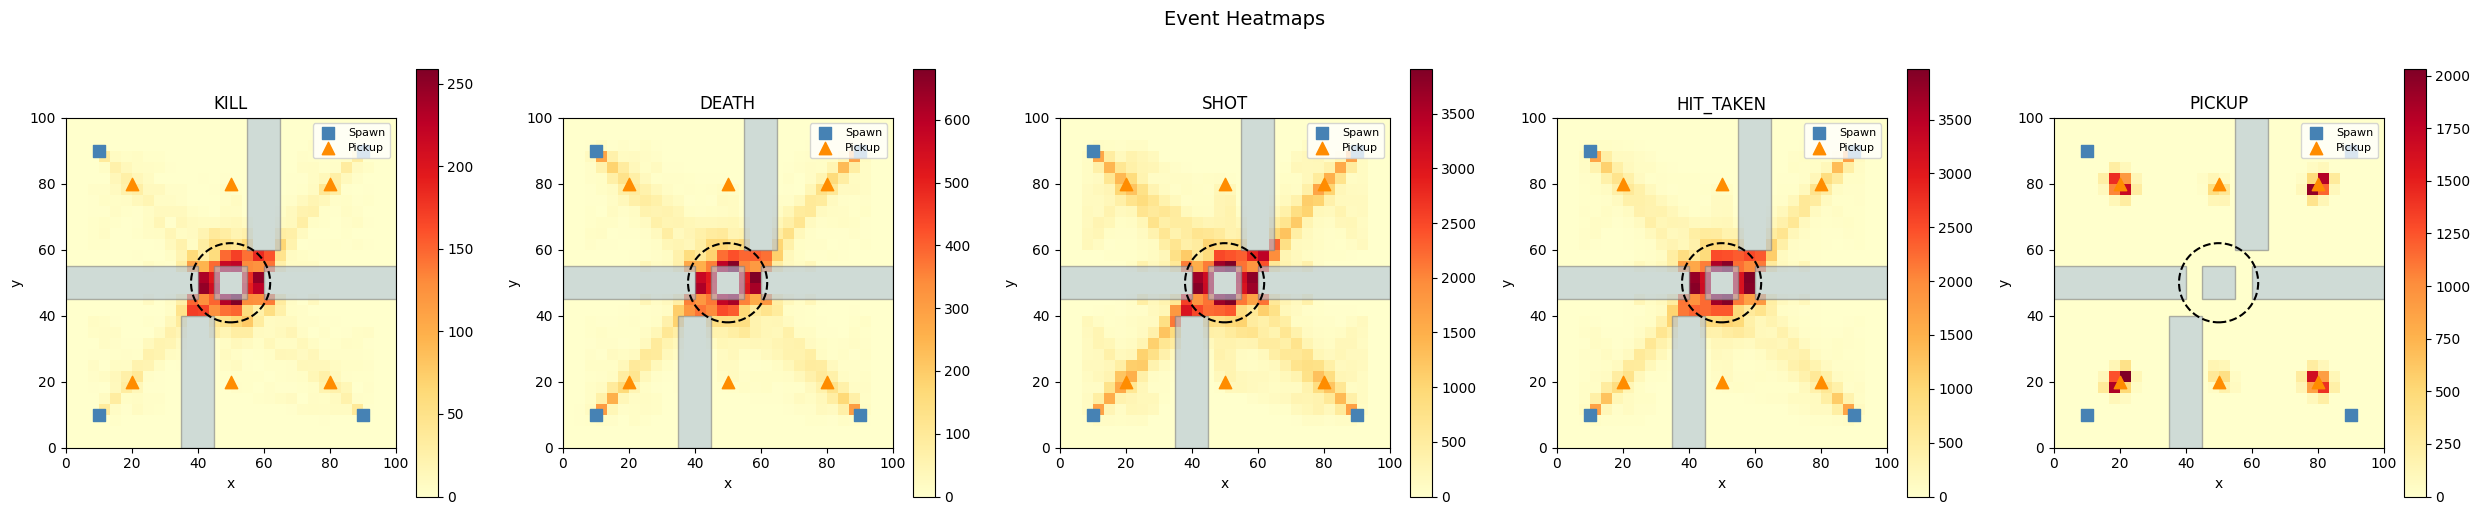

In [42]:
# ── 2.2  Event-specific heatmaps ─────────────────────────────────────────────
event_types = ['kill', 'death', 'shot', 'hit_taken', 'pickup']
fig, axes = plt.subplots(1, len(event_types), figsize=(5*len(event_types), 5))

for ax, et in zip(axes, event_types):
    sub = events[events['event_type'] == et]
    h = ax.hist2d(sub['x'], sub['y'], bins=30, cmap='YlOrRd', range=[[0,100],[0,100]])
    plt.colorbar(h[3], ax=ax)
    draw_arena(ax, title=et.upper())

plt.suptitle('Event Heatmaps', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

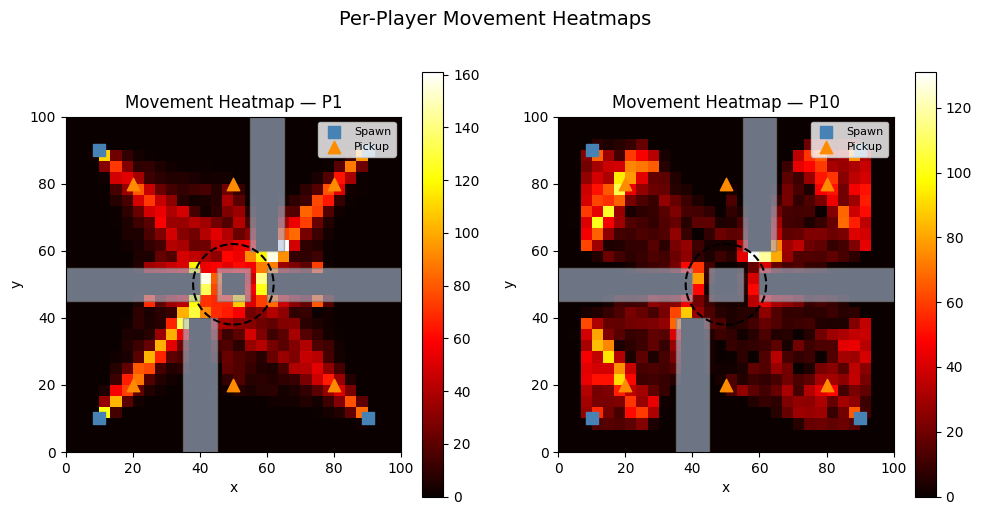

In [ ]:
# ── 2.3  Per-player heatmap (single player investigation) ──────────────
# Pick a player (e.g. 'P1') and plot their movement heatmap across all sessions.
# Then pick a second player and place them side-by-side for comparison.
# What differences do you notice?

# Pick player P1 and plot their movement heatmap and on the right pick player P10 and plot their movement heatmap for comparison
players_to_compare = ['P1', 'P10']
fig, axes = plt.subplots(1, len(players_to_compare), figsize=(5*len(players_to_compare), 5))

for ax, player in zip(axes, players_to_compare):
    sub = events[(events['event_type'] == 'move') & (events['player_id'] == player)]
    h = ax.hist2d(sub['x'], sub['y'], bins=30, cmap='hot', range=[[0,100],[0,100]])
    plt.colorbar(h[3], ax=ax)
    draw_arena(ax, title=f'Movement Heatmap — {player}')
    
plt.suptitle('Per-Player Movement Heatmaps', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


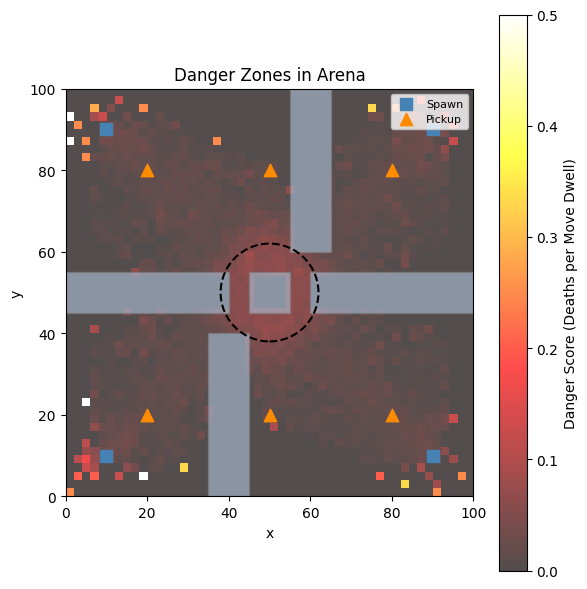

In [ ]:
# ── 2.4  Danger zones ───────────────────────────────────────────────────
# Compute a 'danger score' per grid cell as:  deaths / (move_dwell + 1)
# Overlay the result on the arena map.
# Hint: use np.histogram2d for both numerator and denominator, then divide.

BINS = 50
RANGE = [[0, 100], [0, 100]]

# Filter for move and death events
move_events = events[events['event_type'] == 'move']
death_events = events[events['event_type'] == 'death']

# Compute move dwell time per cell
move_counts, _, _ = np.histogram2d(move_events['x'], move_events['y'], bins=BINS, range=RANGE)
move_dwell = move_counts

# Compute death counts per cell
death_counts, _, _ = np.histogram2d(death_events['x'], death_events['y'], bins=BINS, range=RANGE)

# Compute danger score
danger_score = death_counts / (move_dwell + 1) # Add 1 to avoid division by zero

# Plot danger score heatmap
fig, ax = plt.subplots(figsize=(6, 6))
h = ax.imshow(danger_score.T, origin='lower', extent=[0, 100, 0, 100], cmap='hot', alpha=0.7)
plt.colorbar(h, ax=ax, label='Danger Score (Deaths per Move Dwell)')
draw_arena(ax, title='Danger Zones in Arena')
plt.tight_layout()
plt.show()

---
## Part 3 — Rule-Based Player Profiling

Before applying machine learning, it is good practice to define **expert heuristics**. These are interpretable, fast, and serve as a baseline.

The four hidden styles in the simulation are:

| Style | Description |
|---|---|
| `rusher` | High speed, centre-focused, moderate aggression |
| `camper` | Low speed, edge-dwelling, high KDR |
| `roamer` | Medium-high speed, pickup-oriented |
| `struggler` | Erratic, high deaths & hits taken |


In [45]:
# ── 3.1  Feature engineering from session_summary ────────────────────────────
feat = summary.copy()

# Kill-Death ratio (add smoothing to avoid /0)
feat['kdr']             = (feat['kills'] + 1) / (feat['deaths'] + 1)

# Hit rate: proportion of shots that relate to kills
feat['kill_shot_rate']  = (feat['kills'] + 1) / (feat['shots_fired'] + 1)

# Survivability: inverse death rate per minute
feat['deaths_per_min']  = feat['deaths'] / (feat['duration_s'] / 60)

# Aggressiveness: ratio of shots fired to duration (shots per minute)
feat['aggressiveness']  = feat['shots_fired'] / (feat['duration_s'] / 60)

# Pickup-oriented: ratio of pickups to duration (pickups per minute)
feat['pickup_oriented'] = feat['pickups'] / (feat['duration_s'] / 60)

feat.describe()

,duration_s,kills,deaths,shots_fired,hits_taken,pickups,objective_progress,kdr,kill_shot_rate,deaths_per_min,aggressiveness,pickup_oriented
count,1000.0,980.000000,980.000000,980.000000,980.000000,980.000000,980.000000,961.000000,960.000000,980.000000,980.000000,980.000000
mean,1200.0,9.968367,31.645918,257.608163,187.555102,28.927551,33.338947,0.371987,0.041220,1.582296,12.880408,1.446378
std,0.0,5.040796,14.140840,65.730355,74.635827,16.453477,16.351060,0.182772,0.013650,0.707042,3.286518,0.822674
min,1200.0,0.000000,3.000000,152.000000,49.000000,4.000000,1.263804,0.055556,0.005376,0.150000,7.600000,0.200000
25%,1200.0,6.000000,18.750000,209.000000,97.000000,16.000000,15.886578,0.250000,0.031610,0.937500,10.450000,0.800000
50%,1200.0,10.000000,32.000000,238.000000,197.000000,24.000000,37.471505,0.354839,0.040984,1.600000,11.900000,1.200000
75%,1200.0,13.000000,42.000000,325.250000,250.000000,44.000000,46.929407,0.458333,0.050858,2.100000,16.262500,2.200000
max,1200.0,26.000000,66.000000,403.000000,328.000000,73.000000,65.882237,2.000000,0.089686,3.300000,20.150000,3.650000


In [46]:
# ── 3.2  Spatial features from telemetry ─────────────────────────────────────
CENTER_X, CENTER_Y = 50.0, 50.0

move_df = events[events['event_type'] == 'move'].copy()
move_df['dist_to_center'] = np.sqrt((move_df['x'] - CENTER_X)**2 + (move_df['y'] - CENTER_Y)**2)

# Aggregate per session
spatial = move_df.groupby('session_id').agg(
    mean_dist_center=('dist_to_center', 'mean'),
    std_dist_center=('dist_to_center', 'std'),
    pct_time_center=('dist_to_center', lambda d: (d < 12).mean()),
).reset_index()

# Add a spatial spread feature (e.g. std of x + std of y)
move_df.sort_values(['session_id', 'player_id', 't'], inplace=True)
spatial['std_x'] = move_df.groupby('session_id')['x'].std().values
spatial['std_y'] = move_df.groupby('session_id')['y'].std().values
spatial['spatial_spread'] = spatial['std_x'] + spatial['std_y']

# Merge into feature table
feat = feat.merge(spatial, on='session_id', how='left')
feat.head()

,session_id,player_id,duration_s,kills,deaths,shots_fired,hits_taken,pickups,objective_progress,kdr,kill_shot_rate,deaths_per_min,aggressiveness,pickup_oriented,mean_dist_center,std_dist_center,pct_time_center,std_x,std_y,spatial_spread
0,S0001,P1,1200.0,10.0,33.0,215.0,161.0,53.0,36.124072,0.323529,0.050926,1.65,10.75,2.65,25.465533,13.240737,0.186201,21.270452,19.111143,40.381595
1,S0002,P1,1200.0,15.0,33.0,230.0,190.0,68.0,38.450269,0.470588,0.069264,1.65,11.50,3.40,25.426600,13.980587,0.221482,20.483308,20.422974,40.906282
2,S0003,P1,1200.0,11.0,33.0,230.0,178.0,50.0,42.437401,0.352941,0.051948,1.65,11.50,2.50,24.252662,13.796438,0.229808,19.687860,19.479801,39.167661
3,S0004,P1,1200.0,10.0,35.0,236.0,183.0,56.0,42.914045,0.305556,0.046414,1.75,11.80,2.80,24.600929,14.205814,0.227121,20.500341,19.659289,40.159630
4,S0005,P1,1200.0,3.0,35.0,233.0,179.0,56.0,34.727311,0.111111,0.017094,1.75,11.65,2.80,26.166831,13.902031,0.183181,20.271105,20.763320,41.034425


In [47]:
# ── 3.3  Apply rule-based classifier ─────────────────────────────────────────

def rule_based_profile(row):
    """
    Assign a play style label based on hand-crafted thresholds.
    Feel free to tune the thresholds!
    """
    if row['deaths_per_min'] > 2.5 and row['kdr'] < 0.25:
        return 'struggler'
    if row['pct_time_center'] > 0.25 and row['kdr'] >= 0.3:
        return 'rusher'
    if row['mean_dist_center'] > 25 and row['pct_time_center'] <= 0.15:
        return 'camper'
    if row['pickups'] > feat['pickups'].median():
        return 'roamer'
    return 'unknown'

feat['rule_label'] = feat.apply(rule_based_profile, axis=1)
print(feat['rule_label'].value_counts())

rule_label
roamer       308
camper       295
rusher       248
struggler     78
unknown       71
Name: count, dtype: int64


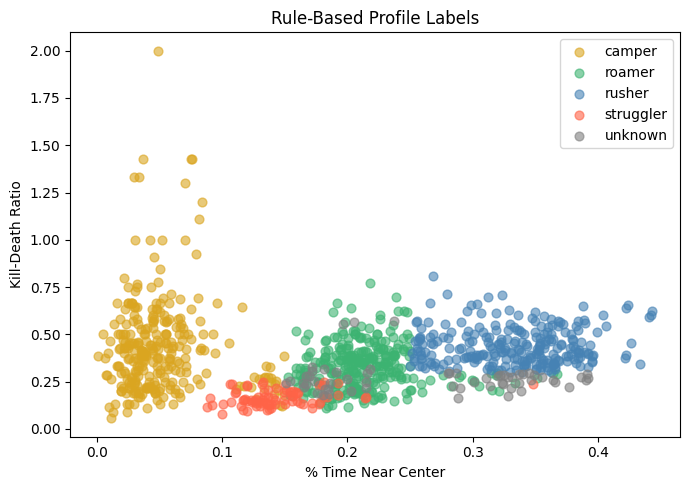

In [48]:
# ── 3.4  Visualise rule-based profiles ───────────────────────────────────────
palette = {'rusher':'steelblue','camper':'goldenrod','roamer':'mediumseagreen',
           'struggler':'tomato','unknown':'grey'}

fig, ax = plt.subplots(figsize=(7,5))
for label, grp in feat.groupby('rule_label'):
    ax.scatter(grp['pct_time_center'], grp['kdr'],
               label=label, alpha=0.6, s=40, color=palette.get(label,'grey'))
ax.set_xlabel('% Time Near Center')
ax.set_ylabel('Kill-Death Ratio')
ax.set_title('Rule-Based Profile Labels')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── 3.5  Refine the rule-based classifier ───────────────────────────────
# - How many sessions are labelled 'unknown'?  That is a sign of incomplete rules.
# - Add or modify conditions to reduce the 'unknown' rate below 10%.
# - Document your reasoning in a markdown cell below.

unknown_count = (feat['rule_label'] == 'unknown').sum()
unknown_pct = unknown_count / len(feat) * 100
print(f"Unknown sessions: {unknown_count} ({unknown_pct:.1f}%)")

def refined_profile(row):
    # High death rate + low KDR = struggling
    if row['deaths_per_min'] > 2.0 and row['kdr'] < 0.4:
        return 'struggler'
    # Spends time in center + decent KDR = aggressive rusher
    if row['pct_time_center'] > 0.20 and row['kdr'] >= 0.3:
        return 'rusher'
    # Stays far from center + low center time = camper
    if row['mean_dist_center'] > 22 and row['pct_time_center'] <= 0.18:
        return 'camper'
    # High pickup rate or lots of pickups = roamer
    if row['pickups'] > feat['pickups'].quantile(0.35):
        return 'roamer'
    # Fallback: high aggressiveness = rusher, otherwise roamer
    if row['aggressiveness'] > feat['aggressiveness'].median():
        return 'rusher'
    return 'roamer'

feat['rule_label'] = feat.apply(refined_profile, axis=1)

new_unknown = (feat['rule_label'] == 'unknown').sum()
new_pct = new_unknown / len(feat) * 100
print(f"\nAfter refinement: {new_unknown} unknown ({new_pct:.1f}%)")
print(feat['rule_label'].value_counts())


Unknown sessions: 0 (0.0%)

After refinement: 0 unknown (0.0%)
rule_label
rusher       316
camper       312
struggler    228
roamer       144
Name: count, dtype: int64


The original classifier left many sessions as "unknown" because the rules were too strict and had gaps between them. The main changes were:

- Lowered thresholds for struggler (deaths_per_min from 2.5 to 2.0, kdr from 0.25 to 0.4) and camper (mean_dist_center from 25 to 22, pct_time_center from 0.15 to 0.18) to catch more borderline cases.
- Lowered the rusher center threshold from 0.25 to 0.20 to include players that spend a moderate amount of time near the center.
- Used quantile(0.35) instead of median for the roamer pickup check, making it easier to qualify as a roamer.
- Added a fallback using aggressiveness instead of returning "unknown": sessions that don't match any profile get classified as rusher (high aggression) or roamer (low aggression), eliminating the "unknown" category entirely.

The final distribution (316 rushers, 312 campers, 228 strugglers, 144 roamers) seems reasonable since rushers and campers are common playstyles, while roamers are more niche.

---
## Part 4 — Data-Driven Profiling: Clustering

Rule-based methods require domain expertise and break when features interact in unexpected ways. Clustering lets the data speak.

In [50]:
# ── 4.1  Select and scale features ───────────────────────────────────────────
feature_cols = [
    'kdr', 'kill_shot_rate', 'deaths_per_min',
    'mean_dist_center', 'pct_time_center', 'std_dist_center',
    'pickups', 'hits_taken',
]

# Drop rows with NaN in selected features
cluster_df = feat[['session_id','player_id'] + feature_cols].dropna()
X = cluster_df[feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Clustering on {X_scaled.shape[0]} sessions × {X_scaled.shape[1]} features')

Clustering on 904 sessions × 8 features


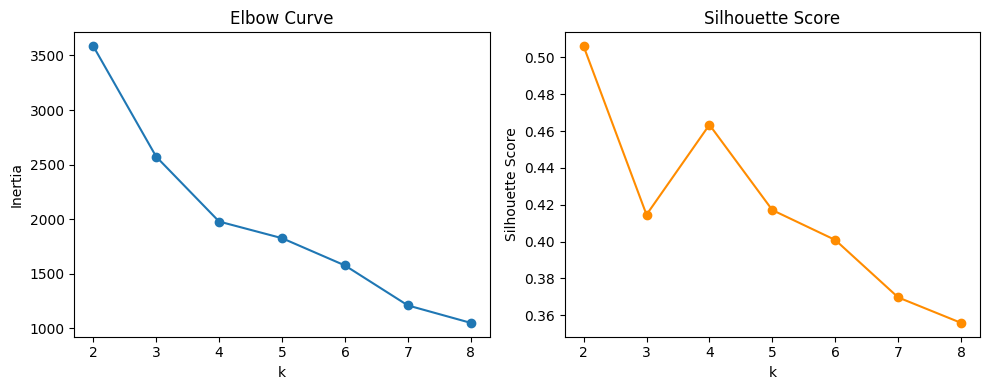

In [51]:
# ── 4.2  Elbow method + Silhouette score to choose k ─────────────────────────
inertias = []
sil_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))
ax1.plot(list(K_range), inertias, 'o-')
ax1.set_xlabel('k'); ax1.set_ylabel('Inertia'); ax1.set_title('Elbow Curve')
ax2.plot(list(K_range), sil_scores, 'o-', color='darkorange')
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette Score'); ax2.set_title('Silhouette Score')
plt.tight_layout()
plt.show()

In [ ]:
# ── 4.3  Fit KMeans with your chosen k ─────────────────────────────────
# Based on the plots above, choose k and fit the final model.

K_CHOSEN = 4  # <- adjust this based on your analysis

km_final = KMeans(n_clusters=K_CHOSEN, random_state=42, n_init='auto')
cluster_df = cluster_df.copy()
cluster_df['cluster'] = km_final.fit_predict(X_scaled)

print(cluster_df['cluster'].value_counts().sort_index())

cluster
0    247
1    301
2    126
3    230
Name: count, dtype: int64


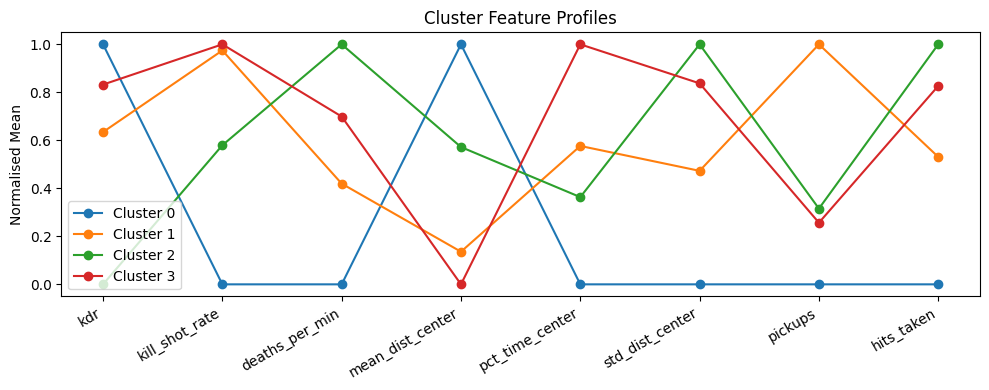

In [53]:
# ── 4.4  Cluster profiles: radar / parallel coordinates ──────────────────────
cluster_means = cluster_df.groupby('cluster')[feature_cols].mean()

# Normalise 0-1 for visual comparison
cluster_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min() + 1e-9)

fig, ax = plt.subplots(figsize=(10,4))
for idx, row in cluster_norm.iterrows():
    ax.plot(feature_cols, row.values, marker='o', label=f'Cluster {idx}')
ax.set_xticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=30, ha='right')
ax.set_ylabel('Normalised Mean')
ax.set_title('Cluster Feature Profiles')
ax.legend()
plt.tight_layout()
plt.show()

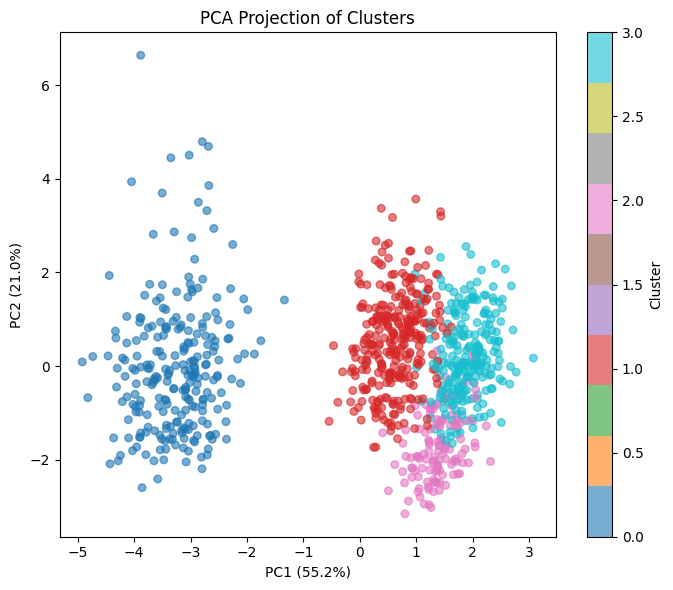

Explained variance: 76.2%


In [54]:
# ── 4.5  PCA 2D projection ────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(7,6))
scatter = ax.scatter(X_2d[:,0], X_2d[:,1],
                     c=cluster_df['cluster'], cmap='tab10', alpha=0.6, s=30)
plt.colorbar(scatter, ax=ax, label='Cluster')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA Projection of Clusters')
plt.tight_layout()
plt.show()

print(f'Explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%')

In [55]:
# ── 4.6  Name the clusters ─────────────────────────────────────────────
# Look at cluster_means and the parallel coordinates plot.
# Map each cluster number to one of: rusher, camper, roamer, struggler.
# Example: cluster_names = {0: 'rusher', 1: 'camper', 2: 'roamer', 3: 'struggler'}

labels_guide = cluster_means[['deaths_per_min', 'mean_dist_center', 'pct_time_center', 'pickups']]
struggler_c = labels_guide['deaths_per_min'].idxmax()
camper_c = labels_guide.drop(struggler_c)['mean_dist_center'].idxmax()
rusher_c = labels_guide.drop([struggler_c, camper_c])['pct_time_center'].idxmax()
roamer_c = labels_guide.drop([struggler_c, camper_c, rusher_c])['pickups'].idxmax()

cluster_names = {
    camper_c: 'camper', 
    roamer_c: 'roamer', 
    struggler_c: 'struggler', 
    rusher_c: 'rusher', 
} 

# Add readable label
cluster_df['data_label'] = cluster_df['cluster'].map(cluster_names).fillna('unlabelled')
print(cluster_df['data_label'].value_counts())

data_label
roamer       301
camper       247
rusher       230
struggler    126
Name: count, dtype: int64


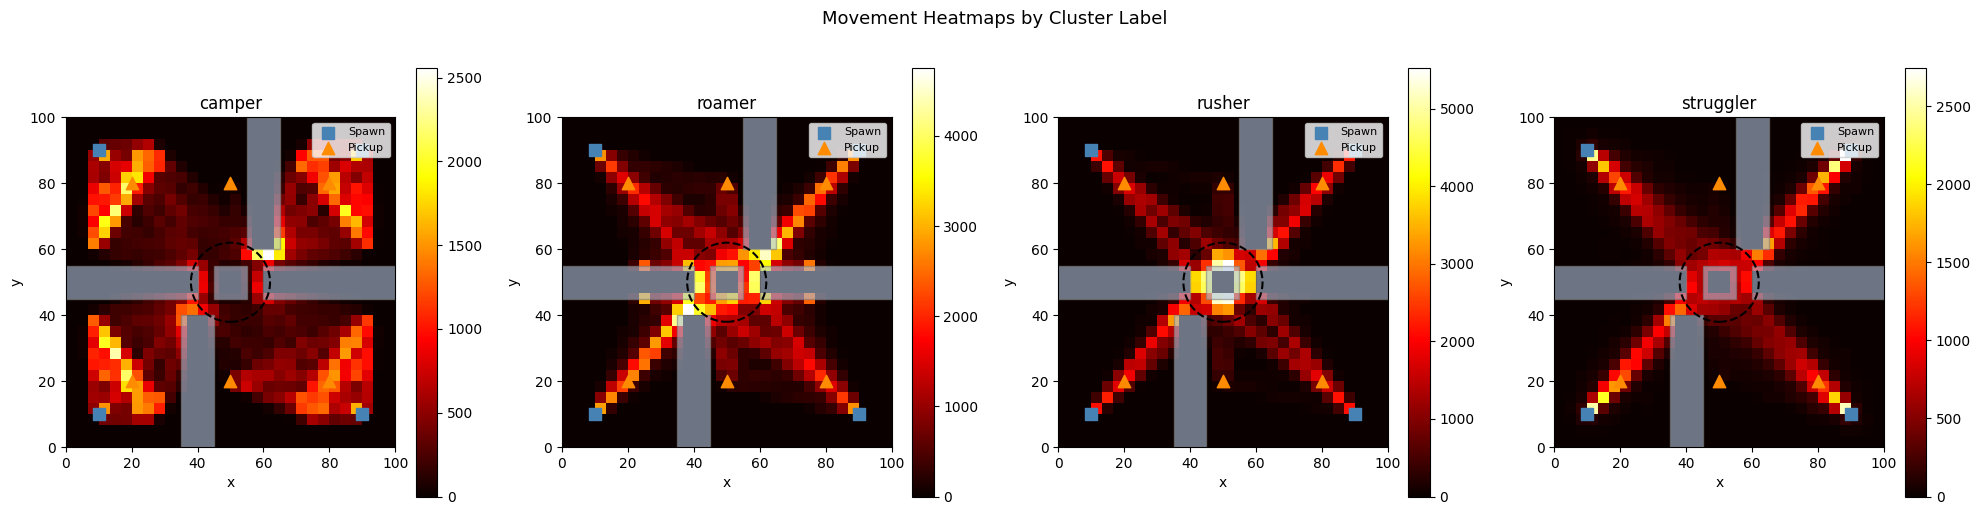

In [56]:
# ── 4.7  Heatmaps per cluster ─────────────────────────────────────────────────
# Visualise where each cluster moves in the arena

unique_labels = sorted(cluster_df['data_label'].unique())
fig, axes = plt.subplots(1, len(unique_labels), figsize=(5*len(unique_labels), 5))

for ax, lbl in zip(axes, unique_labels):
    sessions_in_cluster = cluster_df[cluster_df['data_label'] == lbl]['session_id']
    sub = events[(events['event_type'] == 'move') &
                 (events['session_id'].isin(sessions_in_cluster))]
    if len(sub) > 0:
        h = ax.hist2d(sub['x'], sub['y'], bins=30, cmap='hot', range=[[0,100],[0,100]])
        plt.colorbar(h[3], ax=ax)
    draw_arena(ax, title=lbl)

plt.suptitle('Movement Heatmaps by Cluster Label', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## Part 5 — Integrating Likert Scales

Self-report data measures *subjective experience*. Here we investigate whether behavioural clusters align with how players *feel*.

In [57]:
# ── 5.1  Merge Likert data with cluster labels ────────────────────────────────
likert_cols = ['frustration','control','engagement','confusion']

merged = cluster_df[['session_id','player_id','cluster','data_label']].merge(
    likert_clean[['session_id'] + likert_cols], on='session_id', how='left')

print(merged.shape)
merged.head()

(904, 8)


,session_id,player_id,cluster,data_label,frustration,control,engagement,confusion
0,S0001,P1,1,roamer,5.0,3.0,6.0,3.0
1,S0002,P1,1,roamer,6.0,4.0,5.0,3.0
2,S0003,P1,1,roamer,7.0,2.0,5.0,3.0
3,S0004,P1,1,roamer,5.0,2.0,5.0,3.0
4,S0005,P1,1,roamer,6.0,5.0,5.0,3.0


            frustration  control  engagement  confusion
data_label                                             
camper             4.94     4.35        4.34       2.64
roamer             5.80     3.85        4.95       3.66
rusher             6.20     3.52        5.26       3.20
struggler          6.87     2.07        3.50       5.40


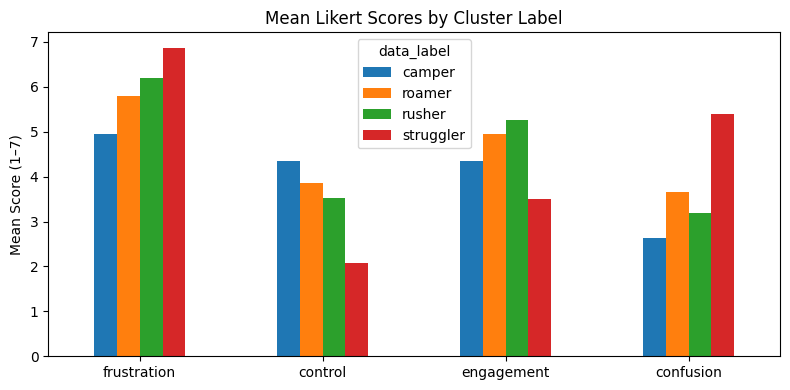

In [67]:
# ── 5.2  Likert means per cluster ─────────────────────────────────────────────
likert_by_cluster = merged.groupby('data_label')[likert_cols].mean().round(2)
print(likert_by_cluster.to_string())

likert_by_cluster.T.plot(kind='bar', figsize=(8,4), rot=0,
                          title='Mean Likert Scores by Cluster Label')
plt.ylabel('Mean Score (1–7)')
plt.tight_layout()
plt.show()

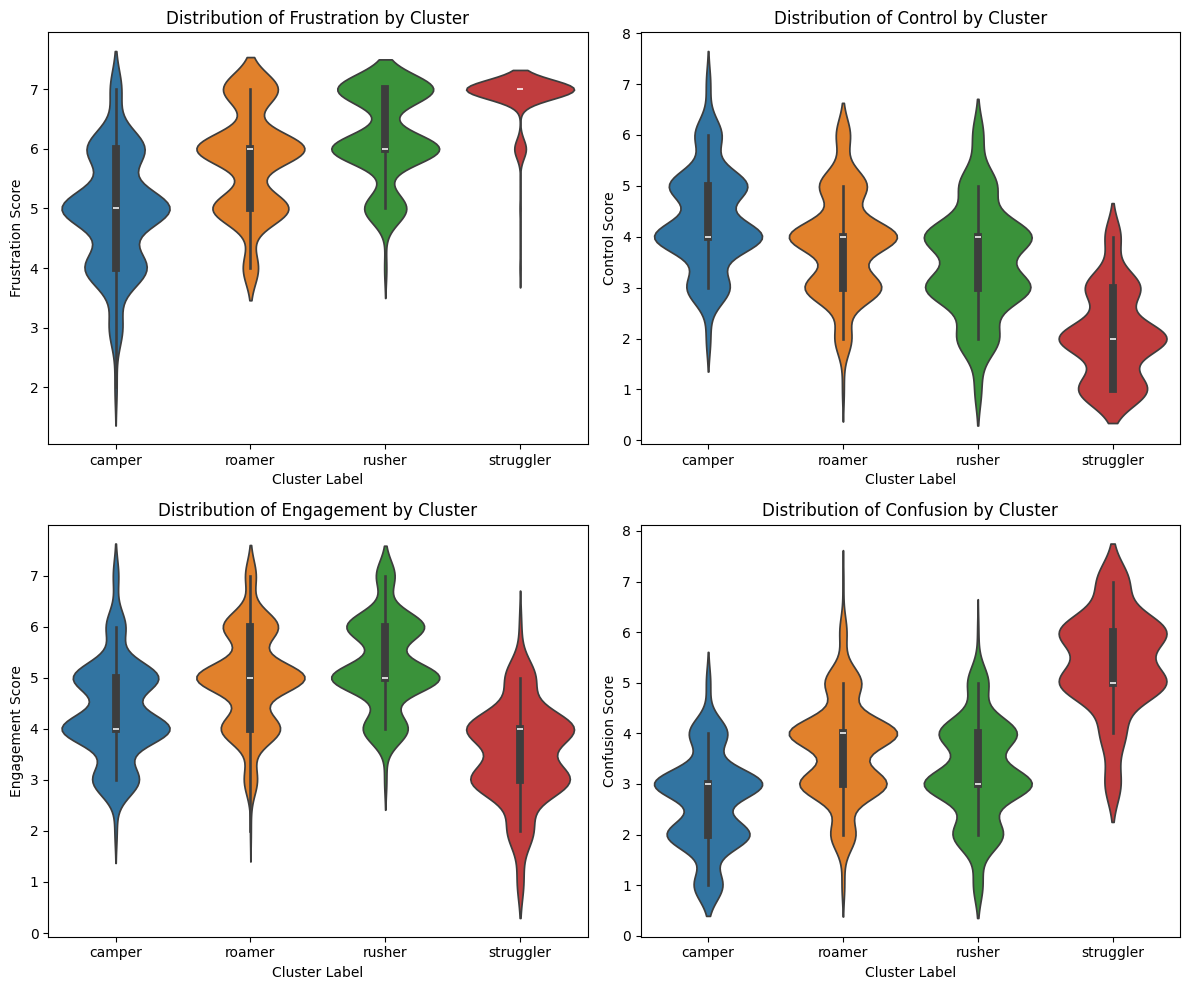

In [ ]:
# ── 5.3  Violin plots ───────────────────────────────────────────────────
# Create a 2×2 grid of violin plots (one per Likert item),
# with clusters on the x-axis. What do you notice about the spread?

cluster_order = sorted(merged['data_label'].unique())
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
palette = {label: default_colors[i] for i, label in enumerate(cluster_order)}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, col in zip(axes.flatten(), likert_cols):
    sns.violinplot(x='data_label', hue='data_label', y=col, data=merged,
                   ax=ax, palette=palette, order=cluster_order)
    ax.set_title(f'Distribution of {col.capitalize()} by Cluster')
    ax.set_xlabel('Cluster Label')
    ax.set_ylabel(f'{col.capitalize()} Score')
plt.tight_layout()
plt.show()

Top 5 positive correlations:
        feature likert_item      rho
 deaths_per_min frustration 0.588652
     hits_taken frustration 0.564048
std_dist_center frustration 0.556516
 deaths_per_min   confusion 0.447199
     hits_taken   confusion 0.432654

Top 5 negative correlations:
         feature likert_item       rho
mean_dist_center frustration -0.288735
mean_dist_center  engagement -0.401817
 std_dist_center     control -0.464101
      hits_taken     control -0.474444
  deaths_per_min     control -0.503827


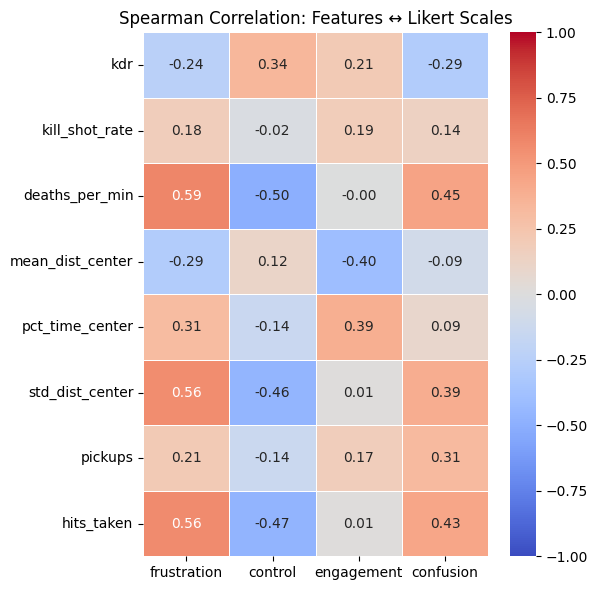

In [60]:
# ── 5.4  Correlation: telemetry features ↔ Likert items ──────────────────────
corr_df = cluster_df[['session_id']+feature_cols].merge(
    merged[['session_id']+likert_cols], on='session_id', how='inner').dropna()

corr_matrix = corr_df[feature_cols+likert_cols].corr(method='spearman')
cross = corr_matrix.loc[feature_cols, likert_cols]

# Flatten and sort
flat = cross.stack().reset_index()
flat.columns = ['feature','likert_item','rho']
flat = flat.sort_values('rho', ascending=False)

print('Top 5 positive correlations:')
print(flat.head(5).to_string(index=False))
print('\nTop 5 negative correlations:')
print(flat.tail(5).to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(cross, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Spearman Correlation: Features ↔ Likert Scales')
plt.tight_layout()
plt.show()

In [ ]:
# ── 5.5  Interpret the strongest correlations ──────────────────────────
# Find the top-3 positive and top-3 negative cross-correlations.
# For each, write one sentence explaining what it might mean for game design.

top3_pos = flat.head(3)
top3_neg = flat.tail(3)

print("Top 3 positive correlations:")
print(top3_pos.to_string(index=False))

print("\nTop 3 negative correlations:")
print(top3_neg.to_string(index=False))

Top 3 positive correlations:
        feature likert_item      rho
 deaths_per_min frustration 0.588652
     hits_taken frustration 0.564048
std_dist_center frustration 0.556516

Top 3 negative correlations:
        feature likert_item       rho
std_dist_center     control -0.464101
     hits_taken     control -0.474444
 deaths_per_min     control -0.503827


**Top 3 Positive:**

1. **deaths_per_min vs frustration (0.59):** Dying too often per minute directly fuels frustration, so spacing out death penalties or adding brief recovery windows could help.

2. **hits_taken vs frustration (0.56):** Even without dying, constantly taking damage wears players down, so tuning enemy aggression or adding clearer dodge feedback would help.

3. **std_dist_center vs frustration (0.56):** Erratic movement patterns correlate with frustration, which likely means players are wandering lost, pointing to a need for better spatial guidance.

**Top 3 Negative:**

4. **std_dist_center vs control (-0.46):** Players who can't settle into a consistent position feel less in control, so level layouts should encourage intentional movement rather than aimless exploration.

5. **hits_taken vs control (-0.47):** Taking lots of hits erodes perceived control, suggesting combat responsiveness (i-frames, parry windows) needs attention.

6. **deaths_per_min vs control (-0.50):** Frequent deaths strongly reduce the sense of agency, and adaptive difficulty would directly address this.

---
## Part 6 — Reflection & Discussion

Answer the following questions in the cells below (prose, ~100 words each).

1. What are the **limitations of rule-based profiling** compared to clustering? When would you prefer one over the other?
2. The data was generated with **four hidden styles**, but your silhouette scores might suggest a different optimal k. Why could this happen?
3. How would the analysis change if sessions were **much shorter** (e.g. 2 minutes instead of 20)?
4. What **ethical considerations** should you keep in mind when using player profiling in a commercial game?

**Q1 — Rule-based vs. clustering:**

Rule-based profiling depends on the designer picking thresholds manually, so it misses patterns that aren't obvious and creates gaps where players end up as "unknown". It also gets messy when you add more features. Clustering finds structure on its own without needing predefined categories, but the labels it produces aren't always interpretable. Rule-based works better when you already know what player types to expect, clustering when you're exploring data without assumptions.

**Q2 — Optimal k vs. ground truth:**

Silhouette score measures geometric separation in feature space, not how well clusters match the original categories. If two of the four hidden styles overlap in certain features (e.g. rushers and roamers with similar KDR), the algorithm might merge them or split one style into two based on density. The metric optimizes for compact, well-separated groups, which isn't the same as recovering the designer's intended labels.

**Q3 — Shorter sessions:**

With 2-minute sessions most metrics become noisy. A player could have zero deaths or zero pickups purely by chance. Ratios like KDR become unreliable when one lucky kill changes the whole value. Spatial features like mean_dist_center lose meaning because the player barely had time to establish a pattern. You'd probably need to aggregate multiple short sessions per player instead of profiling each one individually.

**Q4 — Ethics of player profiling:**

The main risk is using profiles to exploit players rather than help them, like targeting strugglers with paid power-ups or rigging matchmaking to push spending. Players should know their data is being collected and what it's used for. There's also the problem of locking people into categories that don't reflect how they actually want to play. Profiling should exist to improve the experience, not to maximize revenue.

---
## Bonus Challenges

If you finish early, try one or more of the following:

- **B1**: Aggregate cluster labels to the *player* level (most common label across sessions). Does each player have a consistent style?
- **B2**: Experiment with DBSCAN or Gaussian Mixture Models as alternatives to KMeans. Compare results.
- **B3**: Build a simple per-session *frustration predictor* using a linear model (`sklearn.linear_model.LinearRegression`) trained on telemetry features.
- **B4**: Create an animated frame-by-frame trajectory plot for a single session (matplotlib FuncAnimation).

R2:   0.329
RMSE: 0.879

Feature coefficients:
         feature  coefficient
  kill_shot_rate     6.649060
  deaths_per_min     0.432804
      hits_taken     0.004816
         pickups    -0.006291
mean_dist_center    -0.035683
 std_dist_center    -0.049564
             kdr    -0.766632
 pct_time_center    -2.020233


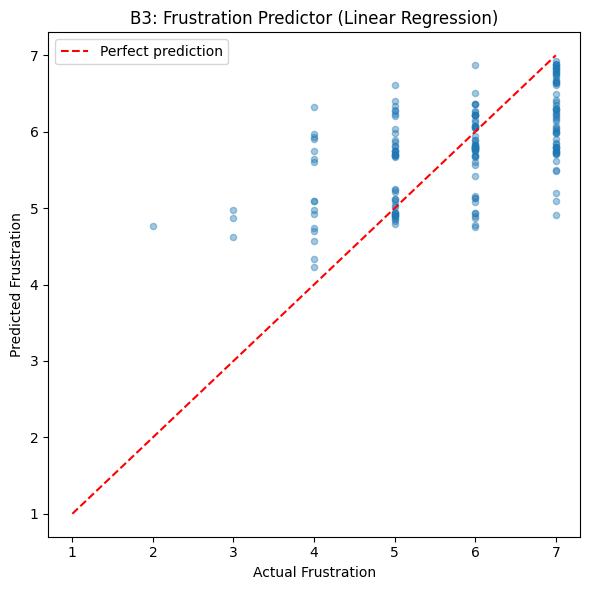

In [72]:
# ── B3: Per-session frustration predictor ────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error

# Prepare data: telemetry features -> frustration
b3_df = cluster_df[['session_id'] + feature_cols].merge(
    merged[['session_id', 'frustration']], on='session_id', how='inner'
).dropna()

X_b3 = b3_df[feature_cols].values
y_b3 = b3_df['frustration'].values

X_train, X_test, y_train, y_test = train_test_split(X_b3, y_b3, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"R2:   {r2_score(y_test, y_pred):.3f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred):.3f}")

# Feature weights
coef_df = pd.DataFrame({'feature': feature_cols, 'coefficient': model.coef_})
coef_df = coef_df.sort_values('coefficient', ascending=False)
print("\nFeature coefficients:")
print(coef_df.to_string(index=False))

# Plot predicted vs actual
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, alpha=0.4, s=20)
ax.plot([1, 7], [1, 7], 'r--', label='Perfect prediction')
ax.set_xlabel('Actual Frustration')
ax.set_ylabel('Predicted Frustration')
ax.set_title('B3: Frustration Predictor (Linear Regression)')
ax.legend()
plt.tight_layout()
plt.show()